In [10]:
from scipy.signal import lfilter
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import numpy as np
from scipy import signal
from IPython.display import Audio
from files.utils import plot_laplace_frequency_response

## Άσκηση - notch φίλτρα και "έξυπνη" αποθορυβοποίηση ήχου


Θυμηθείτε την άσκηση με την αποθορυβοποίηση του μουσικού κομματιού "Ρόζα", των Αλκαίου/Μικρούτσικου σε προηγούμενο Κεφάλαιο, όπου ήταν μολυσμένο με ένα ισχυρό ημίτονο συγκεκριμένης συχνότητας που κληθήκατε να βρείτε κάνοντας συνεχείς μετασχηματισμούς Fourier πάνω στο σήμα - και με τα hints ότι το ημίτονο είχε $A = 0.01$, $\phi = 0$, και η συχνότητα που ψάχνατε ήταν ακέραιο πολλαπλάσιο των $100$ Hz στο διάστημα $[2000, 3000]$ Hz 😃!! 

Όπως είχαμε επισημάνει τότε, το παράδειγμα εκείνο ήταν πολύ εκπαιδευτικό, καθώς σας δινόταν το πλάτος, η φάση, και το "εύρος" που θα έπρεπε να ψάξετε την άγνωστη συχνότητα!

Στην πράξη, δεν μπορεί κανείς να ξέρει το πλάτος και τη φάση του ημιτονοειδούς "θορύβου", ώστε να εκτελέσει τόσο απλά την αφαίρεση $signal(t) -noise(t)$ που κάναμε τότε στο 4ο εργαστήριο, αφού είχαμε κατασκευάσει ένα "αντίγραφο" του ημιτονοειδούς θορύβου. Έτσι, χρησιμοποιούμε τα λεγόμενα **notch** φίλτρα, που αναλαμβάνουν να αποκόψουν μια πολύ πολύ μικρή μπάντα συχνοτήτων, ανεξαρτήτως πλάτους και φάσης. Τα φίλτρα αυτά ουσιαστικά μηδενίζουν το πλάτος μιας ανεπιθύμητης συχνότητας $f_{bad}$, με αποτέλεσμα η φάση να μη μας ενδιαφέρει - το γινόμενο $$0\cdot \cos(2\pi f_{bad} t + \phi)$$ ισούται με $0$, ανεξαρτήτως του $\phi$. Η απόκριση πλάτους ενός notch φίλτρου με συχνότητα αποκοπής $f_c$ φαίνεται στο παρακάτω σχήμα.

<p style="text-align: center"><img src="./files/notch.png" alt="notch" width="600"/></p>

Η σχεδίαση τέτοιων συστημάτων γίνεται κατά κανόνα στο χώρο του μετασχ. Laplace. 

Η θεωρία της κατασκευής της συνάρτησης μεταφοράς $H(s)$ ενός συστήματος notch φίλτρου είναι απλή: για παράδειγμα, αν θέλουμε να μηδενίσουμε τη συχνότητα $f_c = 5000$ Hz του σήματος που θα δεχθεί ως είσοδο το σύστημά μας, τότε:
- Μετατρέπουμε την $f_c$ σε $\omega_c = 2\pi f_c$ για ευκολία, δηλ. $\omega_c = 10000\pi$ rad/s
- Τοποθετούμε δυο **συζυγή μηδενικά** (θυμηθείτε, θέλουμε να μηδενίσουμε μια συχνότητα: όταν πολλαπλασιαστεί η απόκριση συχνότητας με το φάσμα της εισόδου, θα πρέπει το φάσμα εξόδου να έχει τιμή ΜΗΔΕΝ στις ανεπιθύμητες συχνότητες της εισόδου!) **ακριβώς πάνω στο φανταστικό άξονα** στις συχνότητες $\pm 10000\pi$, δημιουργώντας έτσι τον αριθμητή $$P(s) = (s-j\omega_c)(s+j\omega_c) = s^2 + \omega_c^2$$
- Τοποθετούμε δυο **συζυγείς πόλους** στις ίδιες συχνότητες ΑΛΛΑ όχι επάνω στο φανταστικό άξονα: ΚΟΝΤΑ του όμως, από τη μεριά του αριστερού μιγαδικού ημιεπιπέδου (γιατί?), δημιουργώντας έτσι τον παρονομαστή $$Q(s) = (s - s_1)(s - s_1^*) = s^2 + \frac{\omega_c}{Q}s + \omega_c^2$$
- Οι πόλοι ειναι της μορφής $$s_{1,1^*} = -\frac{1}{2Q}\omega_c \pm j\omega_c\sqrt{1 - \left(\frac{1}{2Q}\right)^2}$$
Ο λόγος που οι πόλοι είναι γραμμένοι έτσι δεν είναι του παρόντος 😄 αλλά η μορφή τους μας επιτρέπει, "παίζοντας" με την τιμή του $Q$, να μπορούμε να ελέγχουμε την "αυστηρότητα" του φίλτρου στη συχνότητα αποκοπής. Υψηλή τιμή του $Q$ οδηγεί σε πολύ αυστηρό - στη συχνότητα αποκοπής - φίλτρο αλλά ταυτόχρονα και πολύ "ακριβό" στην υλοποίηση.

- Έτσι, η συνάρτηση μεταφοράς μας θα είναι η 
$$H(s) = \frac{P(s)}{Q(s)} = \frac{s^2 + \omega_c^2}{s^2 + \frac{\omega_c}{Q}s + \omega_c^2}$$

Ας γράψουμε μια συνάρτηση που υλοποιεί ένα τέτοιο φίλτρο. Συμπληρώστε τον κώδικα.

In [11]:
def create_laplace_notch_filter(fc, Q):
    """
    Δημιουργία ενός notch φίλτρου και υλοποίησή του στο χώρο του Laplace.
    
    Παράμετροι:
    fc : Συχνότητα που πρέπει να κοπεί
    Q : Συντελεστής ποιότητας. Όσο ψηλότερος, τόσο αυστηρότερο - και "ακριβότερο" - το φίλτρο στην αποκοπή
        
    Έξοδος:
    numL, denL : Συντελεστές για αριθμητή και παρονομαστή του notch φίλτρου H(s)
    """
    # Συνήθης μορφή του φίλτρου notch: H(s) = (s^2 + ωc^2) / (s^2 + (ωc/Q)s + ωc^2)
    
    # Γωνιακή συχνότητα ωc = 2πfc rad/s
    omegac = 2 * np.pi * fc
    
    # H(s) : αριθμητής : συντελεστές του πολυωνύμου του s
    num_laplace = [1, 0, omegac**2] # INSERT CODE HERE
    
    # H(s) : παρονομαστής : συντελεστές του πολυωνύμου του s
    den_laplace = [1, omegac/Q, omegac**2] # INSERT CODE HERE
    
    return num_laplace, den_laplace

Πριν συνεχίσουμε, ας δούμε γιατί η απλή τοποθέτηση δυο "σκέτων" μηδενικών επάνω στο φανταστικό άξονα, στις συχνότητες $\pm j\omega_c$ ΔΕΝ είναι αρκετή, όπως ίσως θα αναμένατε... 

Ας καλέσουμε τη συνάρτηση που φτιάξαμε, αλλά ας αγνοήσουμε τον παρονομαστή (θεωρώντας τον σταθερό πολυώνυμο, μοναδιαίο), έτσι ώστε να έχει πόλους στο άπειρο και μηδενικά στις θέσεις που θέλουμε. 

Έστω η συχνότητα $f_c = 1560$ Hz που θέλουμε να κόψουμε.

In [12]:
fc = 1560 # Hz
Q = 2
numL, denL = create_laplace_notch_filter(fc, Q) # το κανονικό μας φίλτρο, αμέσως μετά θα αγνοήσουμε τον denL

Σας δίνεται έτοιμη συνάρτηση ``plot_laplace_frequency_response`` που αναλαμβάνει να απεικονίσει την απόκριση πλάτους μέσω της συνάρτησης μεταφοράς που φτιάξατε.

Γράψτε ``help(plot_laplace_frequency_response)`` για να δείτε τη σύνταξή της και μερικές λεπτομέρειες. 

In [13]:
help(plot_laplace_frequency_response)

Help on function plot_laplace_frequency_response in module files.utils:

plot_laplace_frequency_response(num, den, f_min=1, f_max=8000, num_points=4000)
    Εκτύπωση της απόκρισης πλάτους H(f) ενός συστήματος μέσω του μετασχ. Laplace H(s)
    
    Παράμετροι:
    ----------
    num: ndarray
        συντελεστές πολυωνύμου αριθμητή
    den: ndarray
        συντελεστές πολυωνύμου παρονομαστή
    f_min: float
        ελάχιστη συχνότητα απεικόνισης στο H(f)
    f_max: float
        μέγιστη συχνότητα απεικόνισης στο H(f)
    num_points: int
        αριθμός σημείων για τον άξονα των συχνοτήτων
        
    Επιστρέφει:
    -------
    Γράφημα




Ας την καλέσουμε.

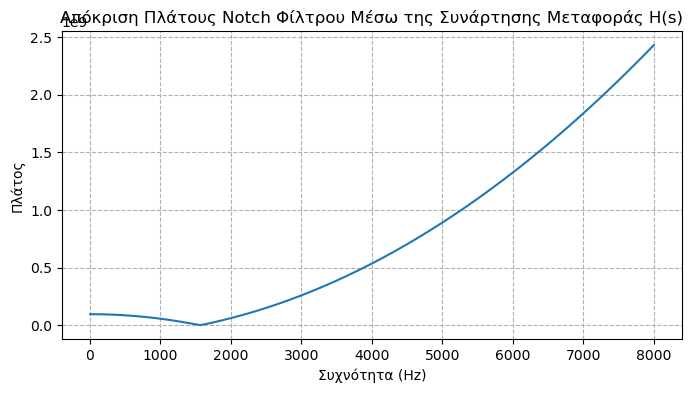

In [14]:
# Βάζουμε [1] ως παρονομαστή για να δηλώσουμε ότι το H(s) είναι πρακτικά 
# μόνο της μορφής H(s) = P(s)/1 = (s^2 + ωc^2)/1 = s^2 + ωc^2
plot_laplace_frequency_response(numL, [1])

Χμμ... πράγματι μηδενίζεται η ζητούμενη συχνότητα των $f_c = \pm 1560$ Hz αλλά η συμπεριφορά του φίλτρου μας δεν είναι καλή, καθώς η απόκριση πλάτους φεύγει στο άπειρο όσο μεγαλώνουν οι συχνότητες, ενισχύοντάς τες ασύλληπτα πολύ. Ταυτόχρονα, οι συχνότητες στο $[0, f_c)$ έχουν πολύ χαμηλότερο πλάτος, συγκριτικά με τις υπόλοιπες. Άρα μόνο η τοποθέτηση δυο μηδενικών στις θέσεις $s = \pm j\omega_c = \pm j2\pi f_c$ ΔΕΝ αρκεί, πράγματι. 

Αν όμως κρατήσουμε και τους πόλους? Τι γίνεται? Ας το δούμε.

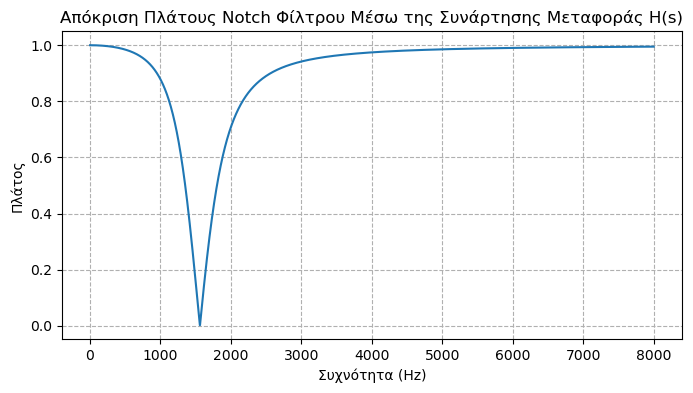

In [15]:
plot_laplace_frequency_response(numL, denL)

Ωωωωω! 😍😍 Τώρα το φίλτρο μας δουλεύει πολύ καλύτερα!! Η συχνότητα $f_c = \pm 1560$ Hz έχει απόλυτο μηδενικό πλάτος, αλλά οι γειτονικές της έχουν επίσης χαμηλότερο από μοναδιαίο πλάτος: δείτε τη συχνότητα των $\pm 2000$ Hz, το πλάτος της είναι $\approx 0.7$, αντί μοναδιαίου. Όμοια η συχνότητα των $\pm 1300$ Hz, με πλάτος $\approx 0.6$, και το ίδιο συμβαίνει και με άλλες εκεί γύρω. Αυτό δεν είναι κάτι που μας αρέσει - αν μπορούμε να το φτιάξουμε - καθώς μειώνουμε το πλάτος "χρήσιμων" συχνοτήτων, δηλ. συχνοτήτων που δε θέλουμε να πειράξουμε. Στην ουσία, το φίλτρο μας δεν είναι πολύ "αυστηρό", "κατεβαίνει απαλά και χαλαρά για να μηδενίσει τη συχνότητα $f_c$, και ανεβαίνει το ίδιο αργά και χαλαρά" - θα έλεγε κάποιος κρατώντας ένα freddo espresso στο χέρι. 😄

Πώς θα φτιάξουμε αυτό το πρόβλημα? Μα ελέγχοντας/αυξάνοντας την τιμή του $Q$ στο φίλτρο μας!

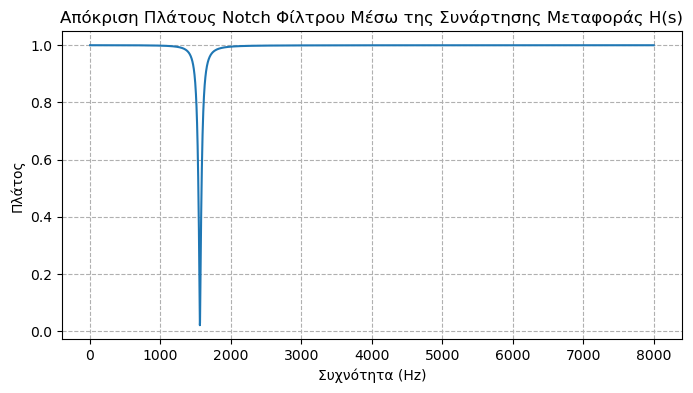

In [16]:
fc = 1560 # Hz
Q = 20 # από 2 σε 20
numL, denL = create_laplace_notch_filter(fc, Q)
plot_laplace_frequency_response(numL, denL)

Wow!! 😍😍 Αυτό πράγματι είναι ένα ΠΟΛΥ καλό φίλτρο! Μπορούμε καλύτερα?

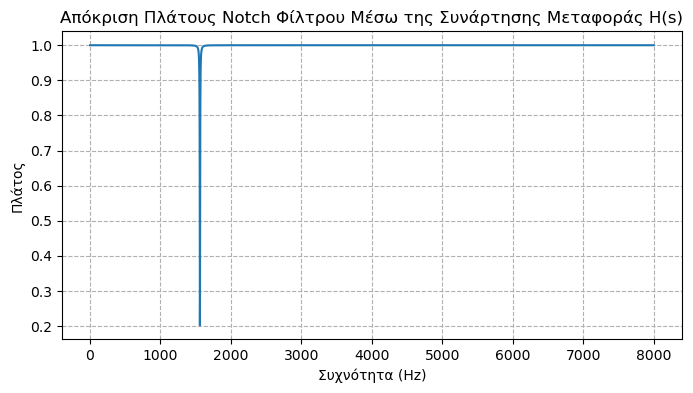

In [17]:
fc = 1560 # Hz
Q = 200 # από 20 σε 200
numL, denL = create_laplace_notch_filter(fc, Q)
plot_laplace_frequency_response(numL, denL)

😃😍 Αυτό είναι ένα εξαιρετικό - και πολύ απαιτητικό - φίλτρο που αποκόπτει τη συχνότητα των $1560$ Hz. 

Μη σας προβληματίζει ότι "μοιάζει" να μη μηδενίζει πλήρως τη συχνότητα $f_c$ (το σχήμα φαίνεται να σταματάει στο $0.2$ και να μην κατεβαίνει στο $0.0$), είναι ζήτημα απεικόνισης και όχι ουσίας. 

---

Ας δούμε τώρα ένα σήμα με ημιτονοειδή θόρυβο, αλλά πλέον δε θα έχετε ΚΑΜΙΑ πληροφορία για τις παραμέτρους του - πλην του ότι η συχνότητα θορύβου είναι ακέραιος αριθμός σε Hz (κι αυτό ξανά για εκπαιδευτικούς λόγους)!

In [ ]:
fs, s = wav.read('./files/BH-noise.wav')  # Φορτώστε το σήμα (BH-noise.wav, που σας δίνεται)
s = s / np.max(np.abs(s))                 # Κανονικοποιήστε τα πλάτη στο [-1, 1]

Audio(s, rate=fs)  # Ας το ακούσουμε - ΧΑΜΗΛΑ ΤΗΝ ΕΝΤΑΣΗ!

Σε αυτήν την άσκηση, είναι προτιμότερο να μην ακολουθήσουμε το μοτίβο του 4ου εργαστηρίου, που διαλέξαμε 12 παράθυρα και είδαμε το μετασχ. Fourier και το φάσμα πλάτους τους ώστε να εντοπίσουμε την άγνωστη συχνότητα. Ας δούμε κάτι διαφορετικό. 

Ο παρακάτω κώδικας υπολογίζει το **φασματογράφημα** ενός σήματος. Όπως είπαμε και στην προηγούμενη άσκηση, αυτό δεν είναι τίποτε άλλο από μια συλλογή φασμάτων πλάτους, σε μια οπτική πιο βολική, που χρησιμοποιεί χρωματικό κώδικα για να δείξει ποιές συχνότητες είναι πιο ισχυρές από τις άλλες.

Μπορείτε να αναγνωρίσετε τη συχνότητα (ή το εύρος στο οποίο βρίσκεται) που έχει "μολύνει" το ηχητικό σήμα?

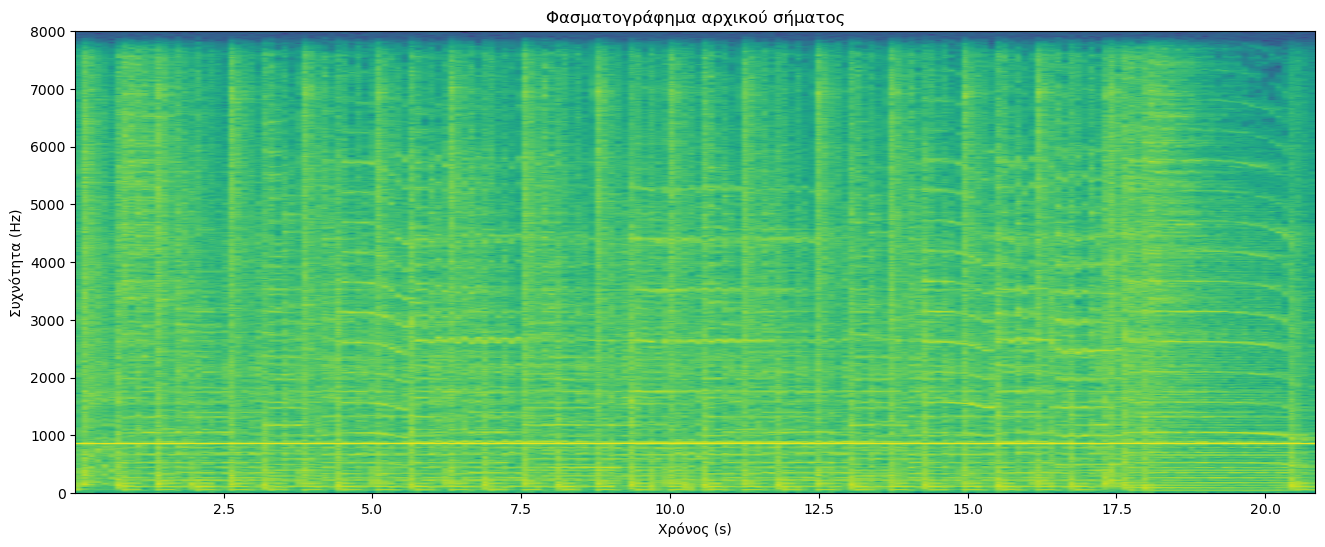

In [27]:
plt.figure(figsize=(16,6))
plt.specgram(x=s, NFFT=2048, Fs=fs, noverlap=256)
plt.title('Φασματογράφημα αρχικού σήματος')
plt.ylabel('Συχνότητα (Hz)')
plt.xlabel('Χρόνος (s)')
plt.show()

Μάλλον είναι πιο δύσκολο απ' ό,τι νομίζατε... σίγουρα αναγνωρίζετε στο σχήμα **που** πρέπει να ψάξετε - σε ποιό **εύρος συχνοτήτων** δηλαδή. 

Στον παρακάτω κώδικα, ορίστε τα όρια $f_1, f_2$ που θέλετε να ψάξετε, και ο κώδικας θα σας επιστρέψει μια "φέτα" του παραπάνω φασματογραφήματος στις συχνότητες $[f_1, f_2]$, ώστε να αναγνωρίσετε τη συχνότητα που θέλετε. 

Ίσως χρειαστεί να πειραματιστείτε 3-4 φορές στις επιλογές σας των $f_1, f_2$ μέχρι να συγκλίνετε σε κάποιο αριθμό.

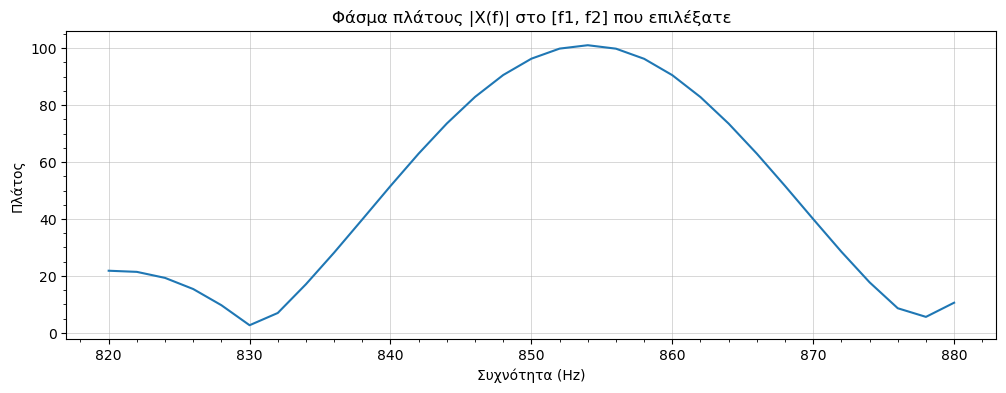

In [20]:
f1 = 820 # INSERT CODE HERE
f2 = 880 # INSERT CODE HERE

NFFT = 8192 # Πλήθος των FFT bins (μεγάλος αριθμός για να κρατήσει η ανάλυση στο zoom)

# Fast Fourier Transform ενός τυχαίου τμήματος του σήματος
X = np.fft.fft(s[1600:2300], NFFT)

# Ζουμάρουμε στο f = [f1, f2]
Xzoom = X[int(2*f1/fs * NFFT/2):int(2*f2/fs * NFFT/2)]

# Άξονας συχνοτήτων f = [f1, f2]
f = np.linspace(f1, f2, len(Xzoom))

# Απεικόνιση του φάσματος πλάτους με λεπτομέρεια
plt.figure(figsize=(12,4))
plt.plot(f, np.abs(Xzoom))
plt.title('Φάσμα πλάτους |X(f)| στο [f1, f2] που επιλέξατε')
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Πλάτος')
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.7)
plt.minorticks_on()
plt.show()

Έχετε μια καλή "μαντεψιά" για τη συχνότητα που θέλετε να κόψετε? Βάλτε την τιμή που νομίζετε παρακάτω.

In [21]:
fc = 852 # INSERT CODE HERE - Ακέραιος αριθμός σε Hz

Ώρα να εφαρμόσουμε το φίλτρο μας???!!! 

Μη βιάζεστε! 😄 Το φίλτρο μας είναι "αναλογικό": είναι χτισμένο στο χώρο του Laplace, που είναι μετασχηματισμός ενός σήματος συνεχούς χρόνου. Το "μολυσμένο" σήμα που σας δίνεται είναι "ψηφιακό". Πρέπει λοιπόν να μετατρέψουμε το αναλογικό φίλτρο σε ψηφιακό. 

**ΕΥΤΥΧΩΣ** η ``Python`` φροντίζει για όλα! 

In [22]:
Q = 200 # δείκτης ποιότητας φίλτρου

# Φίλτρο στο χώρο του Laplace
# ---------------------------
# Τροποποιημένη συχνότητα fc για σωστή λειτουργία της μετατροπής από αναλογικό σε ψηφιακό (don't bother, είναι advanced υλικό)
fc_warped = (fs / np.pi) * np.tan(np.pi * fc / fs)

# Αναλογικό φίλτρο (δηλ. φίλτρο που φιλτράρει σήματα συνεχούς χρόνου)
numL, denL = create_laplace_notch_filter(fc_warped, Q)

# Φίλτρο στον "ψηφιακό" κόσμο
# -------------------------
# Μετατροπή του αναλογικού notch φίλτρου στον "ψηφιακό" κόσμο μέσω διγραμμικού μετασχηματισμού (don't bother, είναι advanced υλικό :) )
b, a = signal.bilinear(numL, denL, fs)

# Φιλτράρισμα
y = lfilter(b, a, s)

Ας ακούσουμε το αρχικό:

In [23]:
Audio(s, rate=fs)  # Πριν τον καθαρισμό

Ας ακούσουμε το "καθαρό": 

In [24]:
Audio(y, rate=fs)  # Μετά τον καθαρισμό

Τα καταφέρατε???? 😃 Αν ακούτε ακόμα το ενοχλητικό ημίτονο, δοκιμάστε μια διαφορετική συχνότητα $f_c$, και τρέξτε ξανά τα τελευταία τμήματα του κώδικα.

---
---